In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
all_data = pd.read_csv('data.csv')
all_data

,x,y,dataset
0,30,3932,train
1,31,4015,train
2,32,4108,train
3,33,4179,train
4,34,4265,train
...,...,...,...
106,110,10630,test
107,115,11040,test
108,120,11460,test
109,125,11875,test


In [3]:
train_data = all_data[all_data['dataset'] == 'train']
train_x = train_data['x']
train_y = train_data['y']

In [4]:
def forward(a,b,x_data):
    y_pr = []
    for x in x_data:
        y_pr.append(a*x+b)
    return y_pr

In [5]:
def tot_loss(y_data,y_pred):
    loss = 0
    for y_pr,y in zip(y_pred,y_data):
        loss += (y_pr - y)**2
    return loss/len(y_data)

In [6]:
def gred_a(x_data,y_data,a,b):
    gred = 0
    for x,y in zip(x_data,y_data):
        gred += 2*(a*x+b - y)*a
    return gred / len(x_data)

def gred_b(x_data,y_data,a,b):
    gred = 0
    for x,y in zip(x_data,y_data):
        gred += 2*(a*x+b - y)
    return gred / len(x_data)

In [7]:
epoch = 1000
a_0 = 80
b_0 = 1500
alpha = 0.0000001

In [8]:
a = a_0
b = b_0
a_new = a_0
t_loss = []
for i in range(epoch):
    y_p = forward(a,b,train_x)
    t_loss.append(tot_loss(train_y,y_p))
    #SGD
    for x,y in zip(train_x,train_y):
        a_new = a - alpha*gred_a([x],[y],a,b)
        b -= alpha*gred_b([x],[y],a,b)
        a = a_new
print('a=',a,'b=',b)

a= 82.82083004760564 b= 1500.0346546052754


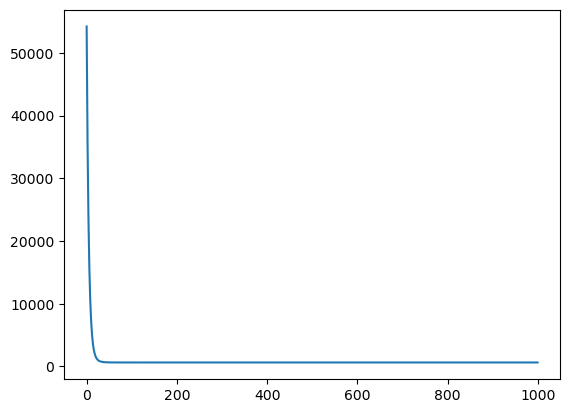

638.9495962234787

In [9]:
plt.plot(t_loss)
plt.show()
t_loss[-1]  #最终loss更小，SGD算法性能更好

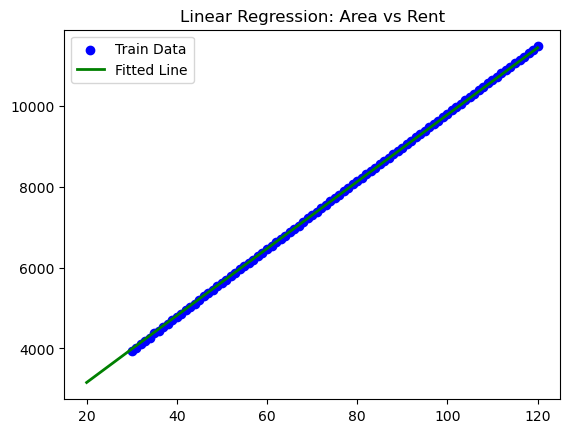

In [10]:
#拟合曲线与数据点
plt.scatter(train_x, train_y, color='blue', label='Train Data')
x_end = np.linspace(20,120,100)
y_end = x_end * a + b
plt.plot(x_end,y_end,color='green', linewidth=2, label='Fitted Line')
plt.legend()
plt.title('Linear Regression: Area vs Rent')
plt.show()